In [1]:
# ==========================================
# GAN IMPLEMENTATION (COMPLETE)
# ==========================================


In [2]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt


c:\Users\mishr\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [3]:

# ------------------------------------------
# 1. Real Data (Gaussian)
# ------------------------------------------
real_data = np.random.normal(0, 1, (2000, 1))


In [4]:

# ------------------------------------------
# 2. Generator
# ------------------------------------------
generator = Sequential([
    Dense(32, activation='relu', input_dim=10),
    Dense(1)
])


c:\Users\mishr\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:

# ------------------------------------------
# 3. Discriminator
# ------------------------------------------
discriminator = Sequential([
    Dense(32, activation='relu', input_dim=1),
    Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer='adam', loss='binary_crossentropy')


In [6]:

# ------------------------------------------
# 4. GAN Model
# ------------------------------------------
discriminator.trainable = False

gan_input = tf.keras.Input(shape=(10,))
fake = generator(gan_input)
gan_output = discriminator(fake)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')


In [7]:

# ------------------------------------------
# 5. Training Loop
# ------------------------------------------
epochs = 1000
d_losses, g_losses = [], []

for epoch in range(epochs):

    noise = np.random.normal(0, 1, (32, 10))
    fake_data = generator.predict(noise, verbose=0)

    real_labels = np.ones((32, 1))
    fake_labels = np.zeros((32, 1))

    d_loss_real = discriminator.train_on_batch(real_data[:32], real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)

    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    noise = np.random.normal(0, 1, (32, 10))
    g_loss = gan.train_on_batch(noise, real_labels)

    d_losses.append(d_loss)
    g_losses.append(g_loss)


c:\Users\mishr\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


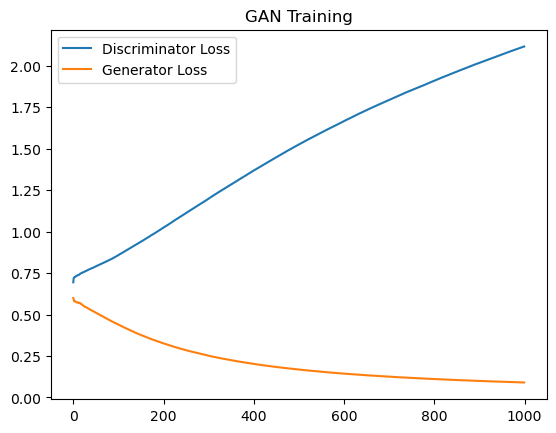

In [8]:

# ------------------------------------------
# 6. Visualization
# ------------------------------------------
plt.figure()
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.legend()
plt.title("GAN Training")
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


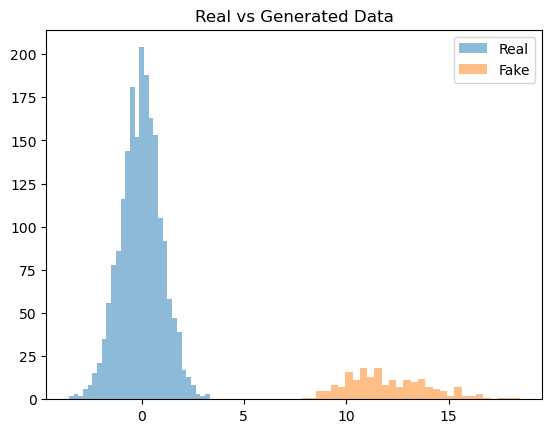

In [9]:

# Generated vs real
fake_samples = generator.predict(np.random.normal(0,1,(200,10)))

plt.hist(real_data, bins=30, alpha=0.5, label="Real")
plt.hist(fake_samples, bins=30, alpha=0.5, label="Fake")
plt.legend()
plt.title("Real vs Generated Data")
plt.show()